# INSIGHTS PLOTS AND GRAPHS

In [2]:
import pandas as pd
df = pd.read_csv('Sample.csv')
print("Shape:", df.shape)
display(df.head())

Shape: (401, 16)


,Email,Name,Gender,10th board,10th marks,12th board,12th marks,Stream,Cgpa,Internships(Y/N),Training(Y/N),Backlog in 5th sem,Innovative Project(Y/N),Communication level,Technical Course(Y/N),Placement(Y/N)?
0,payal_roy79@gmail.com,Payal Roy,Female,State Board,96.7,CBSE,70.2,Mechanical Engineering,7.37,No,Yes,No,No,3,Yes,Not Placed
1,shreyoshi_dey13@gmail.com,Shreyoshi Dey,Female,WBBSE,96.2,WBCHSE,90.6,Electronics and Communication Engineering,9.35,No,No,No,Yes,4,No,Not Placed
2,rohan_nandi12@gmail.com,Rohan Nandi,Male,State Board,97.5,CBSE,69.6,Information Technology,7.84,No,Yes,No,Yes,3,Yes,Placed
3,smita_agarwal90@gmail.com,Smita Agarwal,Female,CBSE,96.9,Other state Board,77.6,Computer Science in AIML,7.87,Yes,No,Yes,Yes,2,Yes,Not Placed
4,samaira_singhania95@gmail.com,Samaira Singhania,Female,ICSE,99.1,CBSE,62.8,Computer Science and Engineering,9.26,Yes,Yes,No,Yes,1,Yes,Not Placed


In [6]:
TARGET_COL = "Placement(Y/N)?"
print("Data types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isna().sum().to_frame("missing_values"))

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nTarget distribution:")
display(df[TARGET_COL].value_counts().to_frame("count"))
display((df[TARGET_COL].value_counts(normalize=True) * 100).round(2).to_frame("percentage"))

Data types:


,dtype
Email,str
Name,str
Gender,str
10th board,str
10th marks,float64
12th board,str
12th marks,float64
Stream,str
Cgpa,float64
Internships(Y/N),str



Missing values:


,missing_values
Email,0
Name,0
Gender,0
10th board,0
10th marks,0
12th board,0
12th marks,0
Stream,0
Cgpa,0
Internships(Y/N),0



Duplicate rows:
0

Target distribution:


,count
Placement(Y/N)?,
Not Placed,202
Placed,199


,percentage
Placement(Y/N)?,
Not Placed,50.37
Placed,49.63


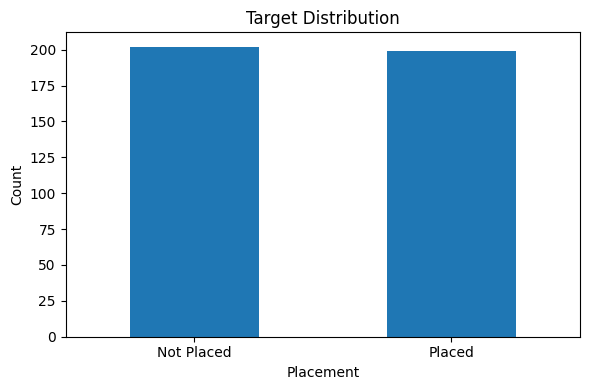

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
df[TARGET_COL].value_counts().plot(kind="bar")
plt.title("Target Distribution")
plt.xlabel("Placement")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [10]:
import numpy as np

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
display(df[num_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
10th marks,401.0,84.512718,9.779359,32.0,77.60,85.20,92.00,100.0
12th marks,401.0,78.798828,10.418821,45.0,70.00,80.50,87.30,97.0
Cgpa,401.0,8.467855,4.154455,5.5,7.62,8.27,8.94,90.0
Communication level,401.0,2.922693,1.378952,1.0,2.00,3.00,4.00,5.0


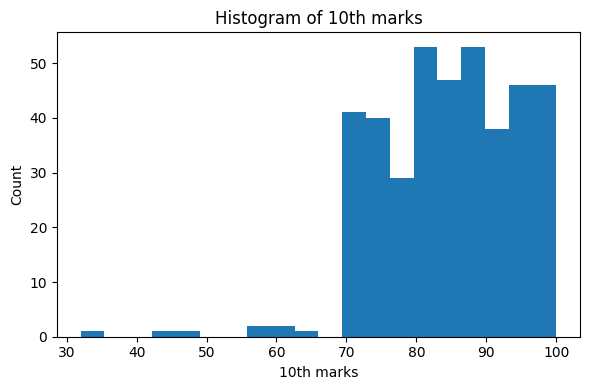

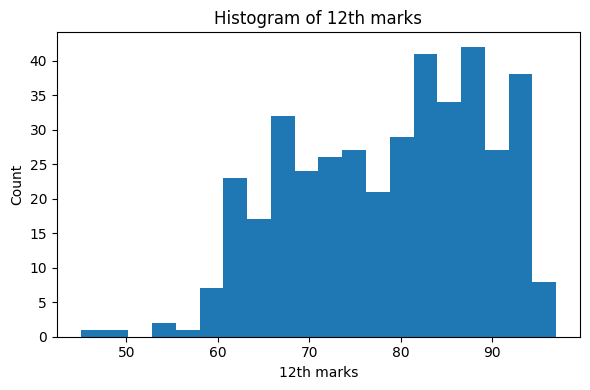

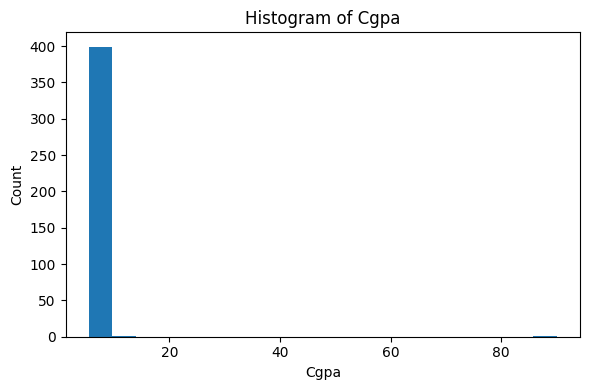

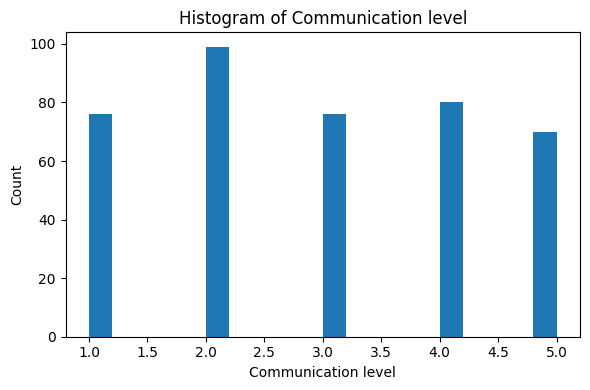

In [11]:
for col in num_cols:
    plt.figure(figsize=(6, 4))
    plt.hist(df[col].dropna(), bins=20)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

# CHECKING OUTLIERS

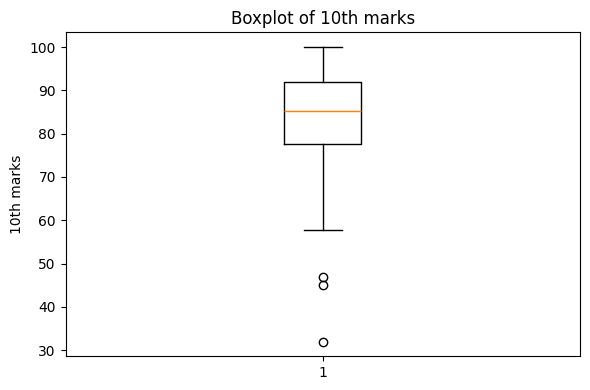

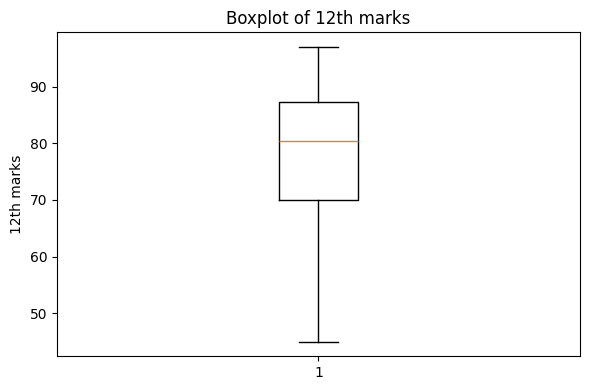

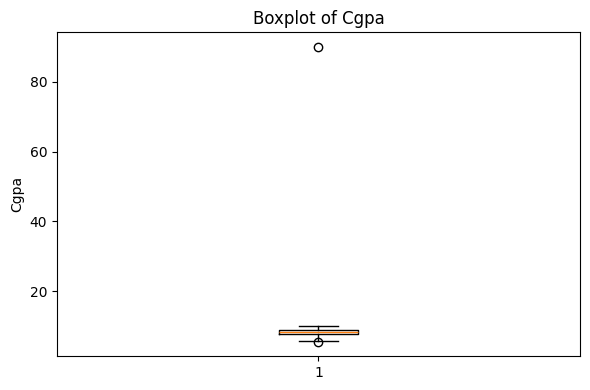

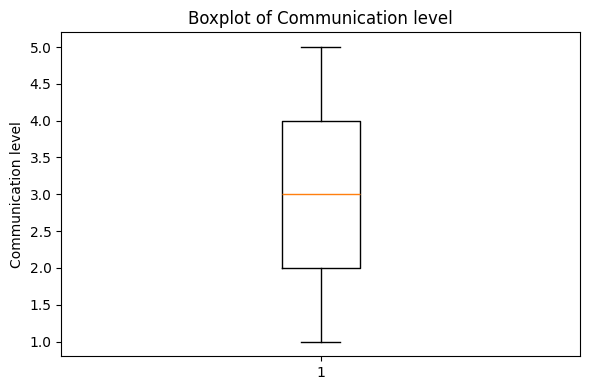

In [12]:
for col in num_cols:
    plt.figure(figsize=(6, 4))
    plt.boxplot(df[col].dropna(), vert=True)
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

In [13]:
def find_outliers_iqr(dataframe, column):
    q1 = dataframe[column].quantile(0.25)
    q3 = dataframe[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = dataframe[(dataframe[column] < lower) | (dataframe[column] > upper)]
    return lower, upper, outliers

for col in num_cols:
    lower, upper, outliers = find_outliers_iqr(df, col)
    print(f"\n{col}")
    print(f"Lower limit: {lower}")
    print(f"Upper limit: {upper}")
    print(f"Outlier count: {outliers.shape[0]}")


10th marks
Lower limit: 55.999999999999986
Upper limit: 113.60000000000001
Outlier count: 3

12th marks
Lower limit: 44.050000000000004
Upper limit: 113.25
Outlier count: 0

Cgpa
Lower limit: 5.640000000000001
Upper limit: 10.919999999999998
Outlier count: 2

Communication level
Lower limit: -1.0
Upper limit: 7.0
Outlier count: 0
